# KNN

Bu kod bloğu, `diabetes.csv` veri kümesine **K-En Yakın Komşular (KNN)** algoritmasını uygulamaktadır.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("diabetes.csv")

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=8)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.7012987012987013

Confusion Matrix
[[85 14]
 [32 23]]

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.86      0.79        99
           1       0.62      0.42      0.50        55

    accuracy                           0.70       154
   macro avg       0.67      0.64      0.64       154
weighted avg       0.69      0.70      0.68       154



# KNN + Ölçekleme + Pipeline

Bu kod bloğu, `diabetes.csv` veri kümesine **K-En Yakın Komşular (KNN)** algoritmasını uygulamaktadır.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=8))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=8))])

In [ ]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7077922077922078


# KNN + Ölçekleme + Boyut İndirgeme (PCA) + Pipeline

Bu kod bloğu, `diabetes.csv` veri kümesine **K-En Yakın Komşular (KNN)** algoritmasını uygulamaktadır.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("knn", KNeighborsClassifier(n_neighbors=8))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('knn', KNeighborsClassifier(n_neighbors=8))])

In [ ]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6493506493506493


# KNN + Ölçekleme + Özellik Seçimi + Pipeline

Bu kod bloğu, `diabetes.csv` veri kümesine **K-En Yakın Komşular (KNN)** algoritmasını uygulamaktadır.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif, k=5)),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=8))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_selection', SelectKBest(k=5)),
                ('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=8))])

In [ ]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


In [ ]:
selector = pipeline.named_steps["feature_selection"]

selected_features = X.columns[selector.get_support()]

print("Seçilen özellikler:")
print(selected_features)

Seçilen özellikler:
Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='object')


In [ ]:
scores = selector.scores_

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores
}).sort_values(by="Score", ascending=False)

print(feature_scores)

                    Feature       Score
1                   Glucose  160.769030
5                       BMI   63.378414
7                       Age   52.326951
0               Pregnancies   27.550001
6  DiabetesPedigreeFunction   14.977704
4                   Insulin    7.290108
2             BloodPressure    4.147608
3             SkinThickness    2.059429


# KNN + Feature Selection + Elbow Method

This notebook applies **K-Nearest Neighbors (KNN)** to the `diabetes.csv` dataset.

Pipeline steps:
1. Feature Selection (SelectKBest)
2. Feature Scaling (StandardScaler)
3. KNN Classification
4. Elbow Method to find the best k value


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Load Dataset

In [ ]:
df = pd.read_csv('diabetes.csv')

X = df.drop('Outcome', axis=1)
y = df['Outcome']

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Elbow Method with Feature Selection

In [ ]:
scores = []
k_values = range(1, 21)

for k in k_values:

    pipeline = Pipeline([
        ('feature_selection', SelectKBest(score_func=f_classif, k=5)),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

## Elbow Graph

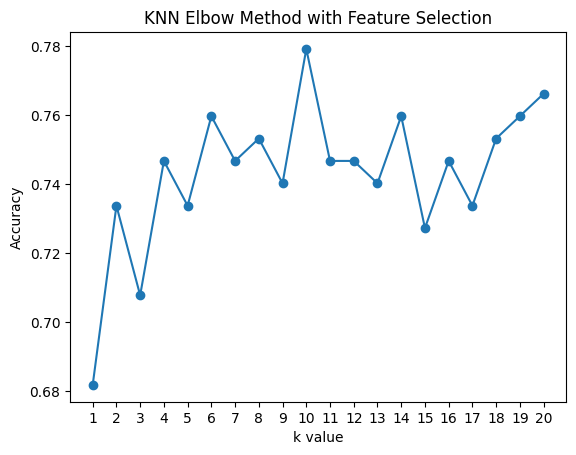

In [ ]:
plt.figure()
plt.plot(list(k_values), scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('KNN Elbow Method with Feature Selection')
plt.xticks(list(k_values))
plt.show()

## Show Selected Features

In [ ]:
pipeline.fit(X_train, y_train)

selector = pipeline.named_steps['feature_selection']

selected_features = X.columns[selector.get_support()]

print('Selected features:')
print(selected_features)

Selected features:
Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='object')
